# 🛰️ AFETSONAR — Phase 1 v2: Building Localization (TAM PAKET)

**Calamitas AI · Teknofest 2025 · Phase 1 — İkinci Deneme**

---

## 📌 Bu Notebook Neden Var?

Phase 1 v1 sonuç: **building IoU = 0.7533** + **erken plato (epoch 5'te)** + **LR schedule bug'ı**.

Senin gözlemlerin:
- ✅ "Her evin sınırını belirleyemedi" — sınırlar kaba
- ✅ "Çok erken plato yaptı" — epoch 5-7'den sonra ilerleme yok
- ✅ "Model öğrenmeye devam etmeli"

Bu notebook 6 kritik iyileştirme ile **plato'yu kırıyor** ve sınır kalitesini artırıyor.

## 🔧 Uygulanan 6 İyileştirme

### 1. LR Bug — KESİN ÇÖZÜM
v1 ve v3'te scheduler'a güvendim, ikisinde de son epoch'larda LR 1e-7'ye düştü. Bu sefer **scheduler yok**, **manuel LR control**. Her epoch başında ben hesaplayıp elle set edeceğim. Bug'a matematiksel olarak yer kalmıyor.

### 2. OHEM (Online Hard Example Mining)
Loss hesaplarken her batch'te:
- Tüm pixel'lerin loss'unu hesapla
- En zor (en yüksek loss) %25 pixel'i seç
- Sadece o pixel'lerden gradient al

Bu, modelin "kolay" pixel'lerde plato yapmasını engeller, "zor" pixel'lere odaklanır.

### 3. Güçlü Augmentation Paketi
v1'de sadece rotate/flip vardı. v2'de:
- RandomScale (±%30)
- GridDistortion + OpticalDistortion (geometrik bozulma)
- RGBShift (renk varyasyonu)
- ElasticTransform (elastic deformation)
- MotionBlur (uydu bulanıklığı simülasyonu)

Model artık "aynı şehri" tekrar tekrar görmüyor → ezber yapmıyor → öğrenmeye devam ediyor.

### 4. Boundary-Aware Loss
Bina kenarlarındaki pixel'lere **2.5x weight**. Bu sınırların pixel-perfect olmasını teşvik eder. Sınır kalitesi artar.

### 5. 80 Epoch + Cosine Warm Restarts
v1'de 40 epoch + düz cosine. v2'de:
- 80 epoch (v1'in 2x'i)
- Her 25 epoch'ta LR **resetleniyor** (warm restart)
- Schedule: 25 ep cosine → reset → 25 ep cosine → reset → 25 ep cosine → 5 ep son fine-tune

Restart'lar plato'yu kırar, model her restart sonrası yeni minima keşfedebilir.

### 6. Küçük Bina Farkındalığı
"Tüm binalar önemli" dedin. Mevcut sample_weight bina **sayısına** bakıyor ama küçük binaları gözardı ediyor. Yeni weight:
- Bina sayısı (mevcut)
- + Hasarlı bina bonus (mevcut)
- + Eğer ortalama bina **küçükse** bonus +3 (yeni)

Böylece "tek küçük yapıdan oluşan" görüntüler de batch'te yer alır.

## ⏱️ Süre

- Eğitim: ~3-4 saat (80 epoch × 2.5 dk)
- H100 önerilir

## 📊 Hedef

- Building IoU: **≥ 0.82** (v1: 0.75)
- Plato olmamalı: epoch 5'te 0.71, epoch 80'de 0.82+ olmalı
- Sınır kalitesi görsel olarak iyileşmeli

## ⚠️ Önemli

v1'in `localizer_best.pth` dosyasının üzerine YAZMAYACAK. Yeni dosya: `localizer_v2_best.pth`. Eski dosya korunuyor (geri dönüş için).

---

## 1️⃣ Drive + GPU

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os

PROJECT_ROOT = "/content/drive/MyDrive/AFETSONAR"
DATA_RAW     = os.path.join(PROJECT_ROOT, "data/raw/xview2")
DATA_MASKS   = os.path.join(PROJECT_ROOT, "data/processed/masks")
DATA_SPLITS  = os.path.join(PROJECT_ROOT, "data/splits")
SRC_DIR      = os.path.join(PROJECT_ROOT, "src")
CKPT_TEACHER = os.path.join(PROJECT_ROOT, "checkpoints/teacher")
OUTPUTS_VIZ  = os.path.join(PROJECT_ROOT, "outputs/visualizations")

required = {
    "train_v2.csv": os.path.join(DATA_SPLITS, "train_v2.csv"),
    "val_v2.csv":   os.path.join(DATA_SPLITS, "val_v2.csv"),
}

print("✅ Drive bağlandı")
for name, path in required.items():
    marker = "✅" if os.path.exists(path) else "❌"
    print(f"  {marker} {name}")

if not all(os.path.exists(p) for p in required.values()):
    raise FileNotFoundError("Notebook 1b çıktıları eksik!")

os.makedirs(CKPT_TEACHER, exist_ok=True)
os.makedirs(OUTPUTS_VIZ, exist_ok=True)

# === GPU ===
import torch
gpu_name = torch.cuda.get_device_name(0)
vram_gb = round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1)
bf16_supported = torch.cuda.is_bf16_supported()
print(f"\n⚙️  {gpu_name}, VRAM: {vram_gb} GB")

# Phase 1 (single image, B3, 768 res)
if "H100" in gpu_name:
    BATCH_SIZE = 16
    GRAD_ACCUM_STEPS = 2  # efektif 32
    NUM_WORKERS = 8
elif "A100" in gpu_name:
    BATCH_SIZE = 12
    GRAD_ACCUM_STEPS = 2
    NUM_WORKERS = 6
elif "L4" in gpu_name or "V100" in gpu_name:
    BATCH_SIZE = 6
    GRAD_ACCUM_STEPS = 4
    NUM_WORKERS = 4
elif "T4" in gpu_name:
    BATCH_SIZE = 3
    GRAD_ACCUM_STEPS = 8
    NUM_WORKERS = 2
else:
    BATCH_SIZE = 6
    GRAD_ACCUM_STEPS = 4
    NUM_WORKERS = 4

EFFECTIVE_BATCH = BATCH_SIZE * GRAD_ACCUM_STEPS
PRECISION = "bf16" if bf16_supported else "fp16"
device = torch.device("cuda")
IMAGE_SIZE = 768

print(f"\n📊 Ayarlar:")
print(f"  micro batch     = {BATCH_SIZE}")
print(f"  grad accum      = {GRAD_ACCUM_STEPS}")
print(f"  effective batch = {EFFECTIVE_BATCH}")
print(f"  image size      = {IMAGE_SIZE}")
print(f"  precision       = {PRECISION}")

Mounted at /content/drive
✅ Drive bağlandı
  ✅ train_v2.csv
  ✅ val_v2.csv

⚙️  NVIDIA A100-SXM4-80GB, VRAM: 79.3 GB

📊 Ayarlar:
  micro batch     = 12
  grad accum      = 2
  effective batch = 24
  image size      = 768
  precision       = bf16


## 2️⃣ Modülleri Yaz

models_v3.py + metrics.py + Phase 1 v2 için inline tanımlar.

In [2]:
import os
import base64

MODELS_PY = base64.b64decode("IiIiCkFGRVRTT05BUiBNb2RlbHMgdjMuCgpUd28gbW9kZWwgY2xhc3NlczoKLSBMb2NhbGl6ZXJTZWdmb3JtZXI6IFBoYXNlIDEsIGJpbmFyeSBidWlsZGluZyBsb2NhbGl6YXRpb24KLSBTaWFtZXNlVGVhY2hlclNlZ2Zvcm1lclYzOiBQaGFzZSAyLCBkYW1hZ2UgY2xhc3NpZmljYXRpb24gd2l0aCBkZWVwIHN1cGVydmlzaW9uCiIiIgoKaW1wb3J0IHRvcmNoCmltcG9ydCB0b3JjaC5ubiBhcyBubgppbXBvcnQgdG9yY2gubm4uZnVuY3Rpb25hbCBhcyBGCmZyb20gdHJhbnNmb3JtZXJzIGltcG9ydCBTZWdmb3JtZXJGb3JTZW1hbnRpY1NlZ21lbnRhdGlvbiwgU2VnZm9ybWVyQ29uZmlnCgoKY2xhc3MgTG9jYWxpemVyU2VnZm9ybWVyKG5uLk1vZHVsZSk6CiAgICBkZWYgX19pbml0X18oCiAgICAgICAgc2VsZiwKICAgICAgICBiYWNrYm9uZV9uYW1lPSJudmlkaWEvc2VnZm9ybWVyLWIzLWZpbmV0dW5lZC1hZGUtNTEyLTUxMiIsCiAgICAgICAgcHJldHJhaW5lZD1UcnVlLAogICAgKToKICAgICAgICBzdXBlcigpLl9faW5pdF9fKCkKICAgICAgICBpZiBwcmV0cmFpbmVkOgogICAgICAgICAgICBzZWxmLnNlZ2Zvcm1lciA9IFNlZ2Zvcm1lckZvclNlbWFudGljU2VnbWVudGF0aW9uLmZyb21fcHJldHJhaW5lZCgKICAgICAgICAgICAgICAgIGJhY2tib25lX25hbWUsCiAgICAgICAgICAgICAgICBudW1fbGFiZWxzPTIsCiAgICAgICAgICAgICAgICBpZ25vcmVfbWlzbWF0Y2hlZF9zaXplcz1UcnVlLAogICAgICAgICAgICApCiAgICAgICAgZWxzZToKICAgICAgICAgICAgY29uZmlnID0gU2VnZm9ybWVyQ29uZmlnLmZyb21fcHJldHJhaW5lZChiYWNrYm9uZV9uYW1lKQogICAgICAgICAgICBjb25maWcubnVtX2xhYmVscyA9IDIKICAgICAgICAgICAgc2VsZi5zZWdmb3JtZXIgPSBTZWdmb3JtZXJGb3JTZW1hbnRpY1NlZ21lbnRhdGlvbihjb25maWcpCgogICAgZGVmIGZvcndhcmQoc2VsZiwgeCk6CiAgICAgICAgQiwgQywgSCwgVyA9IHguc2hhcGUKICAgICAgICBvdXRwdXRzID0gc2VsZi5zZWdmb3JtZXIoeCkKICAgICAgICBsb2dpdHMgPSBvdXRwdXRzLmxvZ2l0cwogICAgICAgIGxvZ2l0cyA9IEYuaW50ZXJwb2xhdGUobG9naXRzLCBzaXplPShILCBXKSwgbW9kZT0iYmlsaW5lYXIiLCBhbGlnbl9jb3JuZXJzPUZhbHNlKQogICAgICAgIHJldHVybiBsb2dpdHMKCiAgICBkZWYgZ2V0X2VuY29kZXJfc3RhdGVfZGljdChzZWxmKToKICAgICAgICBlbmNvZGVyX3N0YXRlID0ge30KICAgICAgICBmb3IgbmFtZSwgcGFyYW0gaW4gc2VsZi5zZWdmb3JtZXIuc2VnZm9ybWVyLmVuY29kZXIuc3RhdGVfZGljdCgpLml0ZW1zKCk6CiAgICAgICAgICAgIGVuY29kZXJfc3RhdGVbbmFtZV0gPSBwYXJhbQogICAgICAgIHJldHVybiBlbmNvZGVyX3N0YXRlCgogICAgZGVmIGVuYWJsZV9ncmFkaWVudF9jaGVja3BvaW50aW5nKHNlbGYpOgogICAgICAgIGlmIGhhc2F0dHIoc2VsZi5zZWdmb3JtZXIuc2VnZm9ybWVyLmVuY29kZXIsICJncmFkaWVudF9jaGVja3BvaW50aW5nX2VuYWJsZSIpOgogICAgICAgICAgICBzZWxmLnNlZ2Zvcm1lci5zZWdmb3JtZXIuZW5jb2Rlci5ncmFkaWVudF9jaGVja3BvaW50aW5nX2VuYWJsZSgpCiAgICAgICAgICAgIHJldHVybiBUcnVlCiAgICAgICAgcmV0dXJuIEZhbHNlCgogICAgZGVmIG51bV9wYXJhbWV0ZXJzKHNlbGYpOgogICAgICAgIHJldHVybiBzdW0ocC5udW1lbCgpIGZvciBwIGluIHNlbGYucGFyYW1ldGVycygpIGlmIHAucmVxdWlyZXNfZ3JhZCkKCgpjbGFzcyBTaWFtZXNlVGVhY2hlclNlZ2Zvcm1lclYzKG5uLk1vZHVsZSk6CiAgICBkZWYgX19pbml0X18oCiAgICAgICAgc2VsZiwKICAgICAgICBiYWNrYm9uZV9uYW1lPSJudmlkaWEvc2VnZm9ybWVyLWIzLWZpbmV0dW5lZC1hZGUtNTEyLTUxMiIsCiAgICAgICAgbnVtX2RhbWFnZV9jbGFzc2VzPTYsCiAgICAgICAgbnVtX2Rpc2FzdGVyX2NsYXNzZXM9NSwKICAgICAgICBwcmV0cmFpbmVkPVRydWUsCiAgICAgICAgdXNlX2RlZXBfc3VwZXJ2aXNpb249VHJ1ZSwKICAgICk6CiAgICAgICAgc3VwZXIoKS5fX2luaXRfXygpCiAgICAgICAgc2VsZi5udW1fZGFtYWdlX2NsYXNzZXMgPSBudW1fZGFtYWdlX2NsYXNzZXMKICAgICAgICBzZWxmLm51bV9kaXNhc3Rlcl9jbGFzc2VzID0gbnVtX2Rpc2FzdGVyX2NsYXNzZXMKICAgICAgICBzZWxmLnVzZV9kZWVwX3N1cGVydmlzaW9uID0gdXNlX2RlZXBfc3VwZXJ2aXNpb24KCiAgICAgICAgaWYgcHJldHJhaW5lZDoKICAgICAgICAgICAgYmFzZV9tb2RlbCA9IFNlZ2Zvcm1lckZvclNlbWFudGljU2VnbWVudGF0aW9uLmZyb21fcHJldHJhaW5lZCgKICAgICAgICAgICAgICAgIGJhY2tib25lX25hbWUsCiAgICAgICAgICAgICAgICBudW1fbGFiZWxzPW51bV9kYW1hZ2VfY2xhc3NlcywKICAgICAgICAgICAgICAgIGlnbm9yZV9taXNtYXRjaGVkX3NpemVzPVRydWUsCiAgICAgICAgICAgICkKICAgICAgICBlbHNlOgogICAgICAgICAgICBjb25maWcgPSBTZWdmb3JtZXJDb25maWcuZnJvbV9wcmV0cmFpbmVkKGJhY2tib25lX25hbWUpCiAgICAgICAgICAgIGNvbmZpZy5udW1fbGFiZWxzID0gbnVtX2RhbWFnZV9jbGFzc2VzCiAgICAgICAgICAgIGJhc2VfbW9kZWwgPSBTZWdmb3JtZXJGb3JTZW1hbnRpY1NlZ21lbnRhdGlvbihjb25maWcpCgogICAgICAgIHNlbGYuZW5jb2RlciA9IGJhc2VfbW9kZWwuc2VnZm9ybWVyLmVuY29kZXIKICAgICAgICBzZWxmLmRlY29kZV9oZWFkID0gYmFzZV9tb2RlbC5kZWNvZGVfaGVhZAoKICAgICAgICBlbmNvZGVyX2NoYW5uZWxzID0gYmFzZV9tb2RlbC5jb25maWcuaGlkZGVuX3NpemVzICAjIFs2NCwgMTI4LCAzMjAsIDUxMl0KICAgICAgICBzZWxmLmVuY29kZXJfY2hhbm5lbHMgPSBlbmNvZGVyX2NoYW5uZWxzCgogICAgICAgIHNlbGYuZnVzaW9uX2NvbnZzID0gbm4uTW9kdWxlTGlzdChbCiAgICAgICAgICAgIG5uLlNlcXVlbnRpYWwoCiAgICAgICAgICAgICAgICBubi5Db252MmQoY2ggKiAzLCBjaCwga2VybmVsX3NpemU9MSwgYmlhcz1GYWxzZSksCiAgICAgICAgICAgICAgICBubi5CYXRjaE5vcm0yZChjaCksCiAgICAgICAgICAgICAgICBubi5SZUxVKGlucGxhY2U9VHJ1ZSksCiAgICAgICAgICAgICkKICAgICAgICAgICAgZm9yIGNoIGluIGVuY29kZXJfY2hhbm5lbHMKICAgICAgICBdKQoKICAgICAgICBpZiB1c2VfZGVlcF9zdXBlcnZpc2lvbjoKICAgICAgICAgICAgc2VsZi5hdXhfaGVhZHMgPSBubi5Nb2R1bGVMaXN0KFsKICAgICAgICAgICAgICAgIG5uLlNlcXVlbnRpYWwoCiAgICAgICAgICAgICAgICAgICAgbm4uQ29udjJkKGNoLCBjaCAvLyAyLCBrZXJuZWxfc2l6ZT0zLCBwYWRkaW5nPTEpLAogICAgICAgICAgICAgICAgICAgIG5uLkJhdGNoTm9ybTJkKGNoIC8vIDIpLAogICAgICAgICAgICAgICAgICAgIG5uLlJlTFUoaW5wbGFjZT1UcnVlKSwKICAgICAgICAgICAgICAgICAgICBubi5Ecm9wb3V0MmQoMC4xKSwKICAgICAgICAgICAgICAgICAgICBubi5Db252MmQoY2ggLy8gMiwgbnVtX2RhbWFnZV9jbGFzc2VzLCBrZXJuZWxfc2l6ZT0xKSwKICAgICAgICAgICAgICAgICkKICAgICAgICAgICAgICAgIGZvciBjaCBpbiBlbmNvZGVyX2NoYW5uZWxzWzotMV0KICAgICAgICAgICAgXSkKICAgICAgICBlbHNlOgogICAgICAgICAgICBzZWxmLmF1eF9oZWFkcyA9IE5vbmUKCiAgICAgICAgbGFzdF9kaW0gPSBlbmNvZGVyX2NoYW5uZWxzWy0xXQogICAgICAgIHNlbGYuY2hhbmdlX2hlYWQgPSBubi5TZXF1ZW50aWFsKAogICAgICAgICAgICBubi5Db252MmQobGFzdF9kaW0sIDI1Niwga2VybmVsX3NpemU9MywgcGFkZGluZz0xKSwKICAgICAgICAgICAgbm4uQmF0Y2hOb3JtMmQoMjU2KSwKICAgICAgICAgICAgbm4uUmVMVShpbnBsYWNlPVRydWUpLAogICAgICAgICAgICBubi5Ecm9wb3V0MmQoMC4xKSwKICAgICAgICAgICAgbm4uQ29udjJkKDI1NiwgMiwga2VybmVsX3NpemU9MSksCiAgICAgICAgKQoKICAgICAgICBzZWxmLmRpc2FzdGVyX2hlYWQgPSBubi5TZXF1ZW50aWFsKAogICAgICAgICAgICBubi5BZGFwdGl2ZUF2Z1Bvb2wyZCgxKSwKICAgICAgICAgICAgbm4uRmxhdHRlbigpLAogICAgICAgICAgICBubi5MaW5lYXIobGFzdF9kaW0sIDI1NiksCiAgICAgICAgICAgIG5uLlJlTFUoaW5wbGFjZT1UcnVlKSwKICAgICAgICAgICAgbm4uRHJvcG91dCgwLjMpLAogICAgICAgICAgICBubi5MaW5lYXIoMjU2LCBudW1fZGlzYXN0ZXJfY2xhc3NlcyksCiAgICAgICAgKQoKICAgIGRlZiBfZW5jb2RlKHNlbGYsIHgpOgogICAgICAgIG91dHB1dHMgPSBzZWxmLmVuY29kZXIoeCwgb3V0cHV0X2hpZGRlbl9zdGF0ZXM9VHJ1ZSwgcmV0dXJuX2RpY3Q9VHJ1ZSkKICAgICAgICByZXR1cm4gbGlzdChvdXRwdXRzLmhpZGRlbl9zdGF0ZXMpCgogICAgZGVmIF9mdXNlX2ZlYXR1cmVzKHNlbGYsIGZlYXR1cmVzX3ByZSwgZmVhdHVyZXNfcG9zdCk6CiAgICAgICAgZnVzZWQgPSBbXQogICAgICAgIGZvciBpLCAocHJlLCBwb3N0KSBpbiBlbnVtZXJhdGUoemlwKGZlYXR1cmVzX3ByZSwgZmVhdHVyZXNfcG9zdCkpOgogICAgICAgICAgICBkaWZmID0gdG9yY2guYWJzKHBvc3QgLSBwcmUpCiAgICAgICAgICAgIGNvbWJpbmVkID0gdG9yY2guY2F0KFtwcmUsIHBvc3QsIGRpZmZdLCBkaW09MSkKICAgICAgICAgICAgZnVzZWRfZmVhdCA9IHNlbGYuZnVzaW9uX2NvbnZzW2ldKGNvbWJpbmVkKQogICAgICAgICAgICBmdXNlZC5hcHBlbmQoZnVzZWRfZmVhdCkKICAgICAgICByZXR1cm4gZnVzZWQKCiAgICBkZWYgZm9yd2FyZChzZWxmLCB4KToKICAgICAgICBCLCBDLCBILCBXID0geC5zaGFwZQogICAgICAgIGFzc2VydCBDID09IDYsIGYiRXhwZWN0ZWQgNiBjaGFubmVscywgZ290IHtDfSIKCiAgICAgICAgcHJlID0geFs6LCA6M10KICAgICAgICBwb3N0ID0geFs6LCAzOl0KCiAgICAgICAgZmVhdHVyZXNfcHJlID0gc2VsZi5fZW5jb2RlKHByZSkKICAgICAgICBmZWF0dXJlc19wb3N0ID0gc2VsZi5fZW5jb2RlKHBvc3QpCiAgICAgICAgZnVzZWRfZmVhdHVyZXMgPSBzZWxmLl9mdXNlX2ZlYXR1cmVzKGZlYXR1cmVzX3ByZSwgZmVhdHVyZXNfcG9zdCkKCiAgICAgICAgZGVjb2Rlcl9vdXRwdXQgPSBzZWxmLmRlY29kZV9oZWFkKGZ1c2VkX2ZlYXR1cmVzKQogICAgICAgIGRhbWFnZV9tYWluID0gRi5pbnRlcnBvbGF0ZSgKICAgICAgICAgICAgZGVjb2Rlcl9vdXRwdXQsCiAgICAgICAgICAgIHNpemU9KEgsIFcpLAogICAgICAgICAgICBtb2RlPSJiaWxpbmVhciIsCiAgICAgICAgICAgIGFsaWduX2Nvcm5lcnM9RmFsc2UsCiAgICAgICAgKQoKICAgICAgICBpZiBzZWxmLnVzZV9kZWVwX3N1cGVydmlzaW9uIGFuZCBzZWxmLmF1eF9oZWFkcyBpcyBub3QgTm9uZToKICAgICAgICAgICAgZGFtYWdlX2xvZ2l0c19saXN0ID0gW2RhbWFnZV9tYWluXQogICAgICAgICAgICBmb3IgaSwgYXV4X2hlYWQgaW4gZW51bWVyYXRlKHNlbGYuYXV4X2hlYWRzKToKICAgICAgICAgICAgICAgIGF1eF9sb2dpdHMgPSBhdXhfaGVhZChmdXNlZF9mZWF0dXJlc1tpXSkKICAgICAgICAgICAgICAgIGF1eF9sb2dpdHMgPSBGLmludGVycG9sYXRlKAogICAgICAgICAgICAgICAgICAgIGF1eF9sb2dpdHMsCiAgICAgICAgICAgICAgICAgICAgc2l6ZT0oSCwgVyksCiAgICAgICAgICAgICAgICAgICAgbW9kZT0iYmlsaW5lYXIiLAogICAgICAgICAgICAgICAgICAgIGFsaWduX2Nvcm5lcnM9RmFsc2UsCiAgICAgICAgICAgICAgICApCiAgICAgICAgICAgICAgICBkYW1hZ2VfbG9naXRzX2xpc3QuYXBwZW5kKGF1eF9sb2dpdHMpCiAgICAgICAgICAgIGRhbWFnZV9vdXRwdXQgPSBkYW1hZ2VfbG9naXRzX2xpc3QKICAgICAgICBlbHNlOgogICAgICAgICAgICBkYW1hZ2Vfb3V0cHV0ID0gZGFtYWdlX21haW4KCiAgICAgICAgbGFzdF9mdXNlZCA9IGZ1c2VkX2ZlYXR1cmVzWy0xXQogICAgICAgIGNoYW5nZV9sb3cgPSBzZWxmLmNoYW5nZV9oZWFkKGxhc3RfZnVzZWQpCiAgICAgICAgY2hhbmdlX2xvZ2l0cyA9IEYuaW50ZXJwb2xhdGUoCiAgICAgICAgICAgIGNoYW5nZV9sb3csCiAgICAgICAgICAgIHNpemU9KEgsIFcpLAogICAgICAgICAgICBtb2RlPSJiaWxpbmVhciIsCiAgICAgICAgICAgIGFsaWduX2Nvcm5lcnM9RmFsc2UsCiAgICAgICAgKQoKICAgICAgICBkaXNhc3Rlcl9sb2dpdHMgPSBzZWxmLmRpc2FzdGVyX2hlYWQobGFzdF9mdXNlZCkKCiAgICAgICAgcmV0dXJuIHsKICAgICAgICAgICAgImRhbWFnZV9sb2dpdHMiOiBkYW1hZ2Vfb3V0cHV0LAogICAgICAgICAgICAiY2hhbmdlX2xvZ2l0cyI6IGNoYW5nZV9sb2dpdHMsCiAgICAgICAgICAgICJkaXNhc3Rlcl9sb2dpdHMiOiBkaXNhc3Rlcl9sb2dpdHMsCiAgICAgICAgfQoKICAgIGRlZiBudW1fcGFyYW1ldGVycyhzZWxmKToKICAgICAgICByZXR1cm4gc3VtKHAubnVtZWwoKSBmb3IgcCBpbiBzZWxmLnBhcmFtZXRlcnMoKSBpZiBwLnJlcXVpcmVzX2dyYWQpCgogICAgZGVmIGVuYWJsZV9ncmFkaWVudF9jaGVja3BvaW50aW5nKHNlbGYpOgogICAgICAgIGlmIGhhc2F0dHIoc2VsZi5lbmNvZGVyLCAiZ3JhZGllbnRfY2hlY2twb2ludGluZ19lbmFibGUiKToKICAgICAgICAgICAgc2VsZi5lbmNvZGVyLmdyYWRpZW50X2NoZWNrcG9pbnRpbmdfZW5hYmxlKCkKICAgICAgICAgICAgcmV0dXJuIFRydWUKICAgICAgICByZXR1cm4gRmFsc2UKCiAgICBkZWYgbG9hZF9lbmNvZGVyX2Zyb21fbG9jYWxpemVyKHNlbGYsIGxvY2FsaXplcl9zdGF0ZV9kaWN0KToKICAgICAgICBvd25fc3RhdGUgPSBzZWxmLmVuY29kZXIuc3RhdGVfZGljdCgpCiAgICAgICAgbG9hZGVkX2NvdW50ID0gMAogICAgICAgIHNraXBwZWQgPSBbXQogICAgICAgIGZvciBuYW1lLCBwYXJhbSBpbiBsb2NhbGl6ZXJfc3RhdGVfZGljdC5pdGVtcygpOgogICAgICAgICAgICBpZiBuYW1lIGluIG93bl9zdGF0ZSBhbmQgb3duX3N0YXRlW25hbWVdLnNoYXBlID09IHBhcmFtLnNoYXBlOgogICAgICAgICAgICAgICAgb3duX3N0YXRlW25hbWVdLmNvcHlfKHBhcmFtKQogICAgICAgICAgICAgICAgbG9hZGVkX2NvdW50ICs9IDEKICAgICAgICAgICAgZWxzZToKICAgICAgICAgICAgICAgIHNraXBwZWQuYXBwZW5kKG5hbWUpCiAgICAgICAgcmV0dXJuIGxvYWRlZF9jb3VudCwgc2tpcHBlZAoKCiMgPT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09CiMgRU1BIFdyYXBwZXIKIyA9PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT0KCmNsYXNzIE1vZGVsRU1BOgogICAgZGVmIF9faW5pdF9fKHNlbGYsIG1vZGVsLCBkZWNheT0wLjk5OSk6CiAgICAgICAgc2VsZi5kZWNheSA9IGRlY2F5CiAgICAgICAgc2VsZi5zaGFkb3cgPSB7fQogICAgICAgIGZvciBuYW1lLCBwYXJhbSBpbiBtb2RlbC5uYW1lZF9wYXJhbWV0ZXJzKCk6CiAgICAgICAgICAgIGlmIHBhcmFtLnJlcXVpcmVzX2dyYWQ6CiAgICAgICAgICAgICAgICBzZWxmLnNoYWRvd1tuYW1lXSA9IHBhcmFtLmRhdGEuY2xvbmUoKS5kZXRhY2goKQoKICAgIEB0b3JjaC5ub19ncmFkKCkKICAgIGRlZiB1cGRhdGUoc2VsZiwgbW9kZWwpOgogICAgICAgIGZvciBuYW1lLCBwYXJhbSBpbiBtb2RlbC5uYW1lZF9wYXJhbWV0ZXJzKCk6CiAgICAgICAgICAgIGlmIHBhcmFtLnJlcXVpcmVzX2dyYWQgYW5kIG5hbWUgaW4gc2VsZi5zaGFkb3c6CiAgICAgICAgICAgICAgICBzZWxmLnNoYWRvd1tuYW1lXS5tdWxfKHNlbGYuZGVjYXkpLmFkZF8oCiAgICAgICAgICAgICAgICAgICAgcGFyYW0uZGF0YSwgYWxwaGE9MS4wIC0gc2VsZi5kZWNheQogICAgICAgICAgICAgICAgKQoKICAgIGRlZiBhcHBseV90byhzZWxmLCBtb2RlbCk6CiAgICAgICAgYmFja3VwID0ge30KICAgICAgICBmb3IgbmFtZSwgcGFyYW0gaW4gbW9kZWwubmFtZWRfcGFyYW1ldGVycygpOgogICAgICAgICAgICBpZiBuYW1lIGluIHNlbGYuc2hhZG93OgogICAgICAgICAgICAgICAgYmFja3VwW25hbWVdID0gcGFyYW0uZGF0YS5jbG9uZSgpCiAgICAgICAgICAgICAgICBwYXJhbS5kYXRhLmNvcHlfKHNlbGYuc2hhZG93W25hbWVdKQogICAgICAgIHJldHVybiBiYWNrdXAKCiAgICBkZWYgcmVzdG9yZShzZWxmLCBtb2RlbCwgYmFja3VwKToKICAgICAgICBmb3IgbmFtZSwgcGFyYW0gaW4gbW9kZWwubmFtZWRfcGFyYW1ldGVycygpOgogICAgICAgICAgICBpZiBuYW1lIGluIGJhY2t1cDoKICAgICAgICAgICAgICAgIHBhcmFtLmRhdGEuY29weV8oYmFja3VwW25hbWVdKQo=").decode("utf-8")
METRICS_PY = base64.b64decode("IiIiCkFGRVRTT05BUiBNZXRyaWNzIOKAlCBzZWdtZW50YXRpb24gKG1Jb1UsIEYxKSBhbmQgY2xhc3NpZmljYXRpb24gKGFjY3VyYWN5KS4KIiIiCgppbXBvcnQgdG9yY2gKaW1wb3J0IG51bXB5IGFzIG5wCgoKY2xhc3MgU2VnbWVudGF0aW9uTWV0cmljczoKICAgICIiIgogICAgU3RyZWFtaW5nIGNvbmZ1c2lvbiBtYXRyaXggZm9yIG11bHRpLWNsYXNzIHNlZ21lbnRhdGlvbi4KCiAgICBVc2FnZToKICAgICAgICBtZXRyaWNzID0gU2VnbWVudGF0aW9uTWV0cmljcyhudW1fY2xhc3Nlcz01KQogICAgICAgIGZvciBiYXRjaCBpbiBsb2FkZXI6CiAgICAgICAgICAgIHByZWRzID0gbW9kZWwoYmF0Y2gpLmFyZ21heChkaW09MSkKICAgICAgICAgICAgbWV0cmljcy51cGRhdGUocHJlZHMsIGJhdGNoWydtYXNrJ10pCiAgICAgICAgc2NvcmVzID0gbWV0cmljcy5jb21wdXRlKCkKICAgICAgICAjIHNjb3JlczogeydtaW91JzogZmxvYXQsICdpb3VfcGVyX2NsYXNzJzogWy4uLl0sICdhY2N1cmFjeSc6IGZsb2F0fQogICAgIiIiCgogICAgZGVmIF9faW5pdF9fKHNlbGYsIG51bV9jbGFzc2VzLCBpZ25vcmVfaW5kZXg9Tm9uZSk6CiAgICAgICAgc2VsZi5udW1fY2xhc3NlcyA9IG51bV9jbGFzc2VzCiAgICAgICAgc2VsZi5pZ25vcmVfaW5kZXggPSBpZ25vcmVfaW5kZXgKICAgICAgICBzZWxmLnJlc2V0KCkKCiAgICBkZWYgcmVzZXQoc2VsZik6CiAgICAgICAgc2VsZi5jb25mdXNpb24gPSBucC56ZXJvcygoc2VsZi5udW1fY2xhc3Nlcywgc2VsZi5udW1fY2xhc3NlcyksIGR0eXBlPW5wLmludDY0KQoKICAgIEB0b3JjaC5ub19ncmFkKCkKICAgIGRlZiB1cGRhdGUoc2VsZiwgcHJlZHMsIHRhcmdldHMpOgogICAgICAgICIiIgogICAgICAgIHByZWRzOiAgIFtCLCBILCBXXSBsb25nIHRlbnNvcgogICAgICAgIHRhcmdldHM6IFtCLCBILCBXXSBsb25nIHRlbnNvcgogICAgICAgICIiIgogICAgICAgIGlmIGlzaW5zdGFuY2UocHJlZHMsIHRvcmNoLlRlbnNvcik6CiAgICAgICAgICAgIHByZWRzID0gcHJlZHMuZGV0YWNoKCkuY3B1KCkubnVtcHkoKQogICAgICAgIGlmIGlzaW5zdGFuY2UodGFyZ2V0cywgdG9yY2guVGVuc29yKToKICAgICAgICAgICAgdGFyZ2V0cyA9IHRhcmdldHMuZGV0YWNoKCkuY3B1KCkubnVtcHkoKQoKICAgICAgICBwcmVkcyA9IHByZWRzLmZsYXR0ZW4oKQogICAgICAgIHRhcmdldHMgPSB0YXJnZXRzLmZsYXR0ZW4oKQoKICAgICAgICBpZiBzZWxmLmlnbm9yZV9pbmRleCBpcyBub3QgTm9uZToKICAgICAgICAgICAgbWFzayA9IHRhcmdldHMgIT0gc2VsZi5pZ25vcmVfaW5kZXgKICAgICAgICAgICAgcHJlZHMgPSBwcmVkc1ttYXNrXQogICAgICAgICAgICB0YXJnZXRzID0gdGFyZ2V0c1ttYXNrXQoKICAgICAgICAjIEZpbHRlciBvdXQtb2YtcmFuZ2UgcHJlZGljdGlvbnMKICAgICAgICB2YWxpZCA9ICh0YXJnZXRzID49IDApICYgKHRhcmdldHMgPCBzZWxmLm51bV9jbGFzc2VzKQogICAgICAgIHByZWRzID0gcHJlZHNbdmFsaWRdCiAgICAgICAgdGFyZ2V0cyA9IHRhcmdldHNbdmFsaWRdCgogICAgICAgICMgQnVpbGQgY29uZnVzaW9uIG1hdHJpeCB1c2luZyBiaW5jb3VudCB0cmljayAoZmFzdCkKICAgICAgICBpZHggPSBzZWxmLm51bV9jbGFzc2VzICogdGFyZ2V0cyArIHByZWRzCiAgICAgICAgYmluYyA9IG5wLmJpbmNvdW50KGlkeCwgbWlubGVuZ3RoPXNlbGYubnVtX2NsYXNzZXMgKiogMikKICAgICAgICBzZWxmLmNvbmZ1c2lvbiArPSBiaW5jLnJlc2hhcGUoc2VsZi5udW1fY2xhc3Nlcywgc2VsZi5udW1fY2xhc3NlcykKCiAgICBkZWYgY29tcHV0ZShzZWxmKToKICAgICAgICAiIiIKICAgICAgICBSZXR1cm5zOgogICAgICAgICAgICB7CiAgICAgICAgICAgICAgICAnbWlvdSc6ICAgICAgICAgICBmbG9hdCwKICAgICAgICAgICAgICAgICdtaW91X25vX2JnJzogICAgIGZsb2F0LCAgIyBtSW9VIHdpdGhvdXQgYmFja2dyb3VuZCBjbGFzcwogICAgICAgICAgICAgICAgJ2lvdV9wZXJfY2xhc3MnOiAgbGlzdCBvZiBmbG9hdHMsCiAgICAgICAgICAgICAgICAnYWNjdXJhY3knOiAgICAgICBmbG9hdCwKICAgICAgICAgICAgICAgICdmMV9wZXJfY2xhc3MnOiAgIGxpc3Qgb2YgZmxvYXRzLAogICAgICAgICAgICAgICAgJ21mMSc6ICAgICAgICAgICAgZmxvYXQsCiAgICAgICAgICAgIH0KICAgICAgICAiIiIKICAgICAgICBjbSA9IHNlbGYuY29uZnVzaW9uLmFzdHlwZShucC5mbG9hdDY0KQoKICAgICAgICAjIElvVSBwZXIgY2xhc3M6IFRQIC8gKFRQICsgRlAgKyBGTikKICAgICAgICB0cCA9IG5wLmRpYWcoY20pCiAgICAgICAgZnAgPSBjbS5zdW0oYXhpcz0wKSAtIHRwCiAgICAgICAgZm4gPSBjbS5zdW0oYXhpcz0xKSAtIHRwCgogICAgICAgIGlvdSA9IHRwIC8gbnAubWF4aW11bSh0cCArIGZwICsgZm4sIDEuMCkKICAgICAgICBpb3VbKHRwICsgZnAgKyBmbikgPT0gMF0gPSBmbG9hdCgibmFuIikgICMgY2xhc3MgbmV2ZXIgc2VlbgoKICAgICAgICAjIEYxIHBlciBjbGFzcwogICAgICAgIHByZWNpc2lvbiA9IHRwIC8gbnAubWF4aW11bSh0cCArIGZwLCAxLjApCiAgICAgICAgcmVjYWxsID0gdHAgLyBucC5tYXhpbXVtKHRwICsgZm4sIDEuMCkKICAgICAgICBmMSA9IDIgKiBwcmVjaXNpb24gKiByZWNhbGwgLyBucC5tYXhpbXVtKHByZWNpc2lvbiArIHJlY2FsbCwgMWUtOCkKICAgICAgICBmMVsodHAgKyBmcCArIGZuKSA9PSAwXSA9IGZsb2F0KCJuYW4iKQoKICAgICAgICAjIFBpeGVsIGFjY3VyYWN5CiAgICAgICAgYWNjdXJhY3kgPSB0cC5zdW0oKSAvIG1heChjbS5zdW0oKSwgMS4wKQoKICAgICAgICBtaW91ID0gbnAubmFubWVhbihpb3UpCiAgICAgICAgbWlvdV9ub19iZyA9IG5wLm5hbm1lYW4oaW91WzE6XSkgICMgc2tpcCBjbGFzcyAwIChiYWNrZ3JvdW5kKQogICAgICAgIG1mMSA9IG5wLm5hbm1lYW4oZjEpCgogICAgICAgIHJldHVybiB7CiAgICAgICAgICAgICJtaW91IjogZmxvYXQobWlvdSksCiAgICAgICAgICAgICJtaW91X25vX2JnIjogZmxvYXQobWlvdV9ub19iZyksCiAgICAgICAgICAgICJpb3VfcGVyX2NsYXNzIjogaW91LnRvbGlzdCgpLAogICAgICAgICAgICAiYWNjdXJhY3kiOiBmbG9hdChhY2N1cmFjeSksCiAgICAgICAgICAgICJmMV9wZXJfY2xhc3MiOiBmMS50b2xpc3QoKSwKICAgICAgICAgICAgIm1mMSI6IGZsb2F0KG1mMSksCiAgICAgICAgfQoKCmNsYXNzIENsYXNzaWZpY2F0aW9uTWV0cmljczoKICAgICIiIgogICAgU2ltcGxlIGFjY3VyYWN5ICsgcGVyLWNsYXNzIGFjY3VyYWN5IGZvciBpbWFnZS1sZXZlbCBjbGFzc2lmaWNhdGlvbi4KICAgICIiIgoKICAgIGRlZiBfX2luaXRfXyhzZWxmLCBudW1fY2xhc3Nlcyk6CiAgICAgICAgc2VsZi5udW1fY2xhc3NlcyA9IG51bV9jbGFzc2VzCiAgICAgICAgc2VsZi5yZXNldCgpCgogICAgZGVmIHJlc2V0KHNlbGYpOgogICAgICAgIHNlbGYuY29ycmVjdCA9IDAKICAgICAgICBzZWxmLnRvdGFsID0gMAogICAgICAgIHNlbGYucGVyX2NsYXNzX2NvcnJlY3QgPSBucC56ZXJvcyhzZWxmLm51bV9jbGFzc2VzLCBkdHlwZT1ucC5pbnQ2NCkKICAgICAgICBzZWxmLnBlcl9jbGFzc190b3RhbCA9IG5wLnplcm9zKHNlbGYubnVtX2NsYXNzZXMsIGR0eXBlPW5wLmludDY0KQoKICAgIEB0b3JjaC5ub19ncmFkKCkKICAgIGRlZiB1cGRhdGUoc2VsZiwgcHJlZHMsIHRhcmdldHMpOgogICAgICAgICIiIgogICAgICAgIHByZWRzOiAgIFtCXSBsb25nIHRlbnNvciAoYXJnbWF4IGFscmVhZHkgZG9uZSkKICAgICAgICB0YXJnZXRzOiBbQl0gbG9uZyB0ZW5zb3IKICAgICAgICAiIiIKICAgICAgICBpZiBpc2luc3RhbmNlKHByZWRzLCB0b3JjaC5UZW5zb3IpOgogICAgICAgICAgICBwcmVkcyA9IHByZWRzLmRldGFjaCgpLmNwdSgpLm51bXB5KCkKICAgICAgICBpZiBpc2luc3RhbmNlKHRhcmdldHMsIHRvcmNoLlRlbnNvcik6CiAgICAgICAgICAgIHRhcmdldHMgPSB0YXJnZXRzLmRldGFjaCgpLmNwdSgpLm51bXB5KCkKCiAgICAgICAgc2VsZi5jb3JyZWN0ICs9IChwcmVkcyA9PSB0YXJnZXRzKS5zdW0oKQogICAgICAgIHNlbGYudG90YWwgKz0gbGVuKHRhcmdldHMpCgogICAgICAgIGZvciBjIGluIHJhbmdlKHNlbGYubnVtX2NsYXNzZXMpOgogICAgICAgICAgICBtYXNrID0gdGFyZ2V0cyA9PSBjCiAgICAgICAgICAgIHNlbGYucGVyX2NsYXNzX2NvcnJlY3RbY10gKz0gKHByZWRzW21hc2tdID09IGMpLnN1bSgpCiAgICAgICAgICAgIHNlbGYucGVyX2NsYXNzX3RvdGFsW2NdICs9IG1hc2suc3VtKCkKCiAgICBkZWYgY29tcHV0ZShzZWxmKToKICAgICAgICBhY2N1cmFjeSA9IHNlbGYuY29ycmVjdCAvIG1heChzZWxmLnRvdGFsLCAxKQogICAgICAgIHBlcl9jbGFzc19hY2MgPSBzZWxmLnBlcl9jbGFzc19jb3JyZWN0IC8gbnAubWF4aW11bShzZWxmLnBlcl9jbGFzc190b3RhbCwgMSkKICAgICAgICByZXR1cm4gewogICAgICAgICAgICAiYWNjdXJhY3kiOiBmbG9hdChhY2N1cmFjeSksCiAgICAgICAgICAgICJwZXJfY2xhc3NfYWNjdXJhY3kiOiBwZXJfY2xhc3NfYWNjLnRvbGlzdCgpLAogICAgICAgICAgICAiYmFsYW5jZWRfYWNjdXJhY3kiOiBmbG9hdChucC5uYW5tZWFuKHBlcl9jbGFzc19hY2MpKSwKICAgICAgICB9Cg==").decode("utf-8")

files_to_write = {
    "models_v3.py": MODELS_PY,
    "metrics.py": METRICS_PY,
}

for filename, content in files_to_write.items():
    full_path = os.path.join(SRC_DIR, filename)
    with open(full_path, "w") as f:
        f.write(content)
    print(f"  ✅ {filename}")

import sys
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import importlib
import models_v3, metrics
importlib.reload(models_v3)
importlib.reload(metrics)

from models_v3 import LocalizerSegformer
from metrics import SegmentationMetrics
print("\n✅ Importlar tamam")

  ✅ models_v3.py
  ✅ metrics.py

✅ Importlar tamam


## 3️⃣ Gelişmiş Loss: OHEM + Boundary-Aware

### OHEM (Online Hard Example Mining)

```
1. Tüm pixel için CE loss hesapla → [B*H*W] tensor
2. En zor %25 pixel'i seç (yüksek loss = zor)
3. Sadece bu pixel'lerden ortalama al
```

### Boundary Loss

```
1. GT mask'ten boundary tespit et (max-min trick)
2. Boundary pixel'lerine 2.5x weight ver
3. CE loss'u bu weight ile çarp
```

### Kombinasyon

```
total_loss = 0.4 * OHEM_CE + 0.4 * Dice + 0.2 * Boundary
```

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class OHEMCrossEntropy(nn.Module):
    # Online Hard Example Mining CE: focus on hardest 25% pixels
    def __init__(self, hard_ratio=0.25, ignore_index=-100):
        super().__init__()
        self.hard_ratio = hard_ratio
        self.ignore_index = ignore_index

    def forward(self, logits, targets):
        # logits: [B, C, H, W], targets: [B, H, W]
        ce = F.cross_entropy(
            logits, targets,
            reduction="none",
            ignore_index=self.ignore_index,
        )  # [B, H, W]

        # Flatten and pick top-k hardest
        ce_flat = ce.view(-1)
        valid_mask = (targets != self.ignore_index).view(-1)
        ce_valid = ce_flat[valid_mask]

        if ce_valid.numel() == 0:
            return ce.mean()

        n_hard = max(1, int(ce_valid.numel() * self.hard_ratio))
        hard_losses, _ = ce_valid.topk(n_hard)
        return hard_losses.mean()


class BoundaryAwareCE(nn.Module):
    # CE with extra weight at class boundaries
    def __init__(self, kernel_size=5, boundary_weight=2.5, ignore_index=-100):
        super().__init__()
        self.kernel_size = kernel_size
        self.boundary_weight = boundary_weight
        self.ignore_index = ignore_index

    @torch.no_grad()
    def _boundary_weights(self, targets):
        # Compute pixel weights: 2.5x at boundary, 1x elsewhere
        valid_mask = (targets != self.ignore_index).float()
        safe_targets = targets.clamp(min=0).float().unsqueeze(1)
        pad = self.kernel_size // 2
        max_pool = F.max_pool2d(safe_targets, self.kernel_size, stride=1, padding=pad)
        min_pool = -F.max_pool2d(-safe_targets, self.kernel_size, stride=1, padding=pad)
        is_boundary = (max_pool != min_pool).float().squeeze(1)
        weights = 1.0 + (self.boundary_weight - 1.0) * is_boundary
        return weights * valid_mask

    def forward(self, logits, targets):
        ce = F.cross_entropy(
            logits, targets,
            reduction="none",
            ignore_index=self.ignore_index,
        )
        weights = self._boundary_weights(targets)
        return (ce * weights).sum() / weights.sum().clamp(min=1.0)


class DiceBinaryLoss(nn.Module):
    # Dice loss for the building class (class 1)
    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        building_prob = probs[:, 1]
        building_target = (targets == 1).float()
        intersection = (building_prob * building_target).sum()
        union = building_prob.sum() + building_target.sum()
        return 1.0 - (2.0 * intersection + 1.0) / (union + 1.0)


class LocalizationLossV2(nn.Module):
    # Combined loss for Phase 1 v2:
    #     0.4 * OHEM_CE + 0.4 * Dice + 0.2 * Boundary
    def __init__(self, hard_ratio=0.25, boundary_weight=2.5):
        super().__init__()
        self.ohem = OHEMCrossEntropy(hard_ratio=hard_ratio)
        self.dice = DiceBinaryLoss()
        self.boundary = BoundaryAwareCE(boundary_weight=boundary_weight)
        self.w_ohem = 0.4
        self.w_dice = 0.4
        self.w_boundary = 0.2

    def forward(self, logits, targets):
        ohem_loss = self.ohem(logits, targets)
        dice_loss = self.dice(logits, targets)
        boundary_loss = self.boundary(logits, targets)
        total = (
            self.w_ohem * ohem_loss
            + self.w_dice * dice_loss
            + self.w_boundary * boundary_loss
        )
        return {
            "total": total,
            "ohem": ohem_loss.detach(),
            "dice": dice_loss.detach(),
            "boundary": boundary_loss.detach(),
        }


# Test
print("🧪 Loss test...")
crit = LocalizationLossV2().to(device)
dummy_logits = torch.randn(2, 2, 64, 64, device=device, requires_grad=True)
dummy_targets = torch.randint(0, 2, (2, 64, 64), device=device)
out = crit(dummy_logits, dummy_targets)
print(f"  total: {out['total'].item():.4f}")
print(f"  ohem:  {out['ohem'].item():.4f}")
print(f"  dice:  {out['dice'].item():.4f}")
print(f"  bnd:   {out['boundary'].item():.4f}")
out["total"].backward()
print(f"  ✅ Backward başarılı")

🧪 Loss test...
  total: 1.1842
  ohem:  1.9853
  dice:  0.5149
  bnd:   0.9208
  ✅ Backward başarılı


## 4️⃣ Güçlü Augmentation Paketi

v1'den çok daha agresif. Ezberi engelliyor, plato'yu kırıyor.

In [4]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

def get_strong_train_aug(image_size):
    return A.Compose([
        A.LongestMaxSize(max_size=image_size + 50),
        A.PadIfNeeded(min_height=image_size, min_width=image_size, border_mode=0),
        A.RandomCrop(height=image_size, width=image_size),

        # Geometric (kompakt)
        A.RandomRotate90(p=0.5),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),

        # Scale variation (yeni!)
        A.RandomScale(scale_limit=0.3, p=0.5),
        A.PadIfNeeded(min_height=image_size, min_width=image_size, border_mode=0),
        A.RandomCrop(height=image_size, width=image_size),

        # Geometric distortion (yeni!)
        A.OneOf([
            A.GridDistortion(num_steps=5, distort_limit=0.3, p=1.0),
            A.OpticalDistortion(distort_limit=0.3, p=1.0),
            A.ElasticTransform(alpha=100, sigma=10, p=1.0),
        ], p=0.4),

        # Color (yeni!)
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.RGBShift(r_shift_limit=20, g_shift_limit=20, b_shift_limit=20, p=0.4),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.3),

        # Blur (yeni - uydu görüntüsü gerçekçiliği)
        A.OneOf([
            A.MotionBlur(blur_limit=5, p=1.0),
            A.GaussianBlur(blur_limit=5, p=1.0),
        ], p=0.2),

        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

def get_val_aug(image_size):
    return A.Compose([
        A.LongestMaxSize(max_size=image_size),
        A.PadIfNeeded(min_height=image_size, min_width=image_size, border_mode=0),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

print("✅ Augmentation hazır")
print("   Train: rotate/flip + scale + distortion + color + blur")
print("   Val:   sadece resize + normalize")

✅ Augmentation hazır
   Train: rotate/flip + scale + distortion + color + blur
   Val:   sadece resize + normalize


## 5️⃣ Dataset + Küçük Bina Farkındalığı

Yeni `LocalizerDatasetV2`:
- Pre image kullanıyor (binalar net görünüyor)
- Building-aware crop (%85 binaya merkezli)
- **Küçük bina bonusu**: ortalama bina alanı küçükse sample weight'e +3 ekle

In [5]:
import cv2
import numpy as np
import pandas as pd
import random
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler


class LocalizerDatasetV2(Dataset):
    # Phase 1 v2 dataset with building-aware crop and pre image
    def __init__(self, csv_path, augmentation=None, image_size=768,
                 building_aware_crop=True, building_crop_prob=0.85):
        self.df = pd.read_csv(csv_path)
        self.augmentation = augmentation
        self.image_size = image_size
        self.building_aware_crop = building_aware_crop
        self.building_crop_prob = building_crop_prob

    def __len__(self):
        return len(self.df)

    def _building_aware_crop(self, img, mask):
        h, w = mask.shape
        target = self.image_size
        if h <= target and w <= target:
            return img, mask

        nonzero = np.where(mask > 0)
        if len(nonzero[0]) == 0 or random.random() > self.building_crop_prob:
            y_start = random.randint(0, max(0, h - target))
            x_start = random.randint(0, max(0, w - target))
        else:
            idx = random.randint(0, len(nonzero[0]) - 1)
            cy, cx = nonzero[0][idx], nonzero[1][idx]
            jitter = target // 4
            y_start = cy - target // 2 + random.randint(-jitter, jitter)
            x_start = cx - target // 2 + random.randint(-jitter, jitter)
            y_start = max(0, min(h - target, y_start))
            x_start = max(0, min(w - target, x_start))

        return img[y_start:y_start+target, x_start:x_start+target], \
               mask[y_start:y_start+target, x_start:x_start+target]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        pre = cv2.imread(row["pre_path"])
        if pre is None:
            pre = np.zeros((self.image_size, self.image_size, 3), dtype=np.uint8)
        else:
            pre = cv2.cvtColor(pre, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
        if mask is None:
            mask = np.zeros(pre.shape[:2], dtype=np.uint8)

        if mask.shape != pre.shape[:2]:
            mask = cv2.resize(mask, (pre.shape[1], pre.shape[0]),
                              interpolation=cv2.INTER_NEAREST)

        binary_mask = (mask > 0).astype(np.uint8)

        if self.building_aware_crop and pre.shape[0] > self.image_size:
            pre, binary_mask = self._building_aware_crop(pre, binary_mask)

        if self.augmentation is not None:
            augmented = self.augmentation(image=pre, mask=binary_mask)
            pre = augmented["image"]
            binary_mask = augmented["mask"]

        if not isinstance(pre, torch.Tensor):
            pre = torch.from_numpy(pre).permute(2, 0, 1).float() / 255.0
        if not isinstance(binary_mask, torch.Tensor):
            binary_mask = torch.from_numpy(binary_mask)

        return {
            "image": pre,
            "mask": binary_mask.long(),
            "filename": row["filename"],
        }


def compute_v2_sample_weights(df):
    # v2 sample weights with small building awareness
    weights = np.ones(len(df), dtype=np.float32)

    for i, row in df.iterrows():
        w = 1.0

        # Hasarlı bina bonus (mevcut)
        n_minor = row.get("n_minor", 0)
        n_major = row.get("n_major", 0)
        n_destroyed = row.get("n_destroyed", 0)
        if n_destroyed > 0:
            w += 3.0
        if n_major > 0:
            w += 2.0
        if n_minor > 0:
            w += 3.0

        # YENİ: küçük bina bonusu
        # Binayı varsa AMA toplam bina pixel'i azsa → küçük binalardan oluşan görüntü
        n_total = sum([
            row.get("n_no_damage", 0),
            row.get("n_minor", 0),
            row.get("n_major", 0),
            row.get("n_destroyed", 0),
            row.get("n_unclassified", 0),
        ])

        # Eğer "n_pixels_*" sütunları varsa onları kullan
        n_pixels_buildings = sum([
            row.get(f"n_pixels_{c}", 0) for c in [1, 2, 3, 4, 5]
        ])

        if n_total > 0 and n_pixels_buildings > 0:
            avg_size = n_pixels_buildings / max(n_total, 1)
            # Küçük binalar (ortalama < 500 pixel ≈ küçük yapı) için bonus
            if avg_size < 500:
                w += 3.0
            elif avg_size < 1000:
                w += 1.5

        weights[i] = w

    return weights


# Datasets
train_aug = get_strong_train_aug(IMAGE_SIZE)
val_aug = get_val_aug(IMAGE_SIZE)

train_ds = LocalizerDatasetV2(
    csv_path=os.path.join(DATA_SPLITS, "train_v2.csv"),
    augmentation=train_aug,
    image_size=IMAGE_SIZE,
    building_aware_crop=True,
    building_crop_prob=0.85,
)

val_ds = LocalizerDatasetV2(
    csv_path=os.path.join(DATA_SPLITS, "val_v2.csv"),
    augmentation=val_aug,
    image_size=IMAGE_SIZE,
    building_aware_crop=False,
)

print(f"📦 Datasets:")
print(f"   train: {len(train_ds)}")
print(f"   val:   {len(val_ds)}")

# Yeni sample weights
print(f"\n⚖️  v2 sample weights hesaplanıyor (küçük bina farkındalığı ile)...")
train_weights = compute_v2_sample_weights(train_ds.df)
print(f"   min:    {train_weights.min():.2f}")
print(f"   max:    {train_weights.max():.2f}")
print(f"   median: {np.median(train_weights):.2f}")
print(f"   mean:   {train_weights.mean():.2f}")

# Sampler
train_sampler = WeightedRandomSampler(
    weights=train_weights.tolist(),
    num_samples=len(train_ds),
    replacement=True,
)

def collate_fn(batch):
    return {
        "image": torch.stack([b["image"] for b in batch]),
        "mask": torch.stack([b["mask"] for b in batch]),
    }

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, sampler=train_sampler,
    num_workers=NUM_WORKERS, collate_fn=collate_fn,
    pin_memory=True, drop_last=True,
    persistent_workers=True if NUM_WORKERS > 0 else False,
)

val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=collate_fn,
    pin_memory=True,
    persistent_workers=True if NUM_WORKERS > 0 else False,
)

print(f"\n   train batches: {len(train_loader)}")
print(f"   val batches:   {len(val_loader)}")

📦 Datasets:
   train: 1959
   val:   420

⚖️  v2 sample weights hesaplanıyor (küçük bina farkındalığı ile)...
   min:    1.00
   max:    1.00
   median: 1.00
   mean:   1.00

   train batches: 163
   val batches:   35


## 6️⃣ Localizer Modelini İnşa Et

In [6]:
import sys
sys.path.insert(0, SRC_DIR)
import importlib
import models_v3
importlib.reload(models_v3)
from models_v3 import LocalizerSegformer

print("🏗️  LocalizerSegformer (B3, 768 res) inşa ediliyor...")
model = LocalizerSegformer(
    backbone_name="nvidia/segformer-b3-finetuned-ade-512-512",
    pretrained=True,
)
model = model.to(device)
print(f"   ✅ {model.num_parameters():,} parametre")

# Forward test
amp_dtype = torch.bfloat16 if PRECISION == "bf16" else torch.float16
model.eval()
with torch.no_grad():
    dummy = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)
    with torch.autocast(device_type="cuda", dtype=amp_dtype):
        out = model(dummy)
print(f"   Output: {tuple(out.shape)}")

mem_gb = torch.cuda.memory_allocated() / 1024**3
print(f"\n💾 GPU bellek: {mem_gb:.2f} GB / {vram_gb} GB")

🏗️  LocalizerSegformer (B3, 768 res) inşa ediliyor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/190M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/644 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b3-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([2])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([2, 768, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


   ✅ 47,224,002 parametre


model.safetensors:   0%|          | 0.00/189M [00:00<?, ?B/s]

   Output: (2, 2, 768, 768)

💾 GPU bellek: 0.21 GB / 79.3 GB


## 7️⃣ Manuel LR Schedule (BUG-FREE)

### Neden manuel?

İki kez scheduler'ı kullandım, iki kez son epoch'larda LR 1e-7'ye düştü. Sebep gradient accumulation ile scheduler.step() sayısı arasında uyumsuzluk.

### Bu sefer çözüm

Scheduler **YOK**. Her epoch başında ben LR'i hesaplayıp `optimizer.param_groups[0]["lr"] = ...` ile elle atıyorum. Matematiksel olarak yanlış olamaz.

### Schedule (Cosine with Warm Restarts)

```
Epoch  1- 3:  warmup (lin 0 → 2e-4)
Epoch  4-25:  cosine (2e-4 → 1e-6)
Epoch 26:     RESTART (LR = 2e-4)
Epoch 27-50:  cosine (2e-4 → 1e-6)
Epoch 51:     RESTART (LR = 1.5e-4)
Epoch 52-75:  cosine (1.5e-4 → 1e-6)
Epoch 76-80:  fine-tune (LR = 1e-5 fixed)
```

In [7]:
from torch.optim import AdamW
import math

# Hyperparameters
NUM_EPOCHS = 80
WARMUP_EPOCHS = 3
WEIGHT_DECAY = 0.01
TEST_MODE = False

if TEST_MODE:
    NUM_EPOCHS = 5

# Restart schedule (epoch numaraları)
RESTART_EPOCHS = [25, 50, 75]  # bu epoch'larda LR resetlenecek
LR_PEAKS = [2e-4, 2e-4, 1.5e-4]  # her segment'in peak LR'i
LR_MIN = 1e-6
LR_FINETUNE = 1e-5  # son 5 epoch için

print(f"⚙️  Hyperparameters:")
print(f"  num_epochs    = {NUM_EPOCHS}")
print(f"  warmup        = {WARMUP_EPOCHS}")
print(f"  weight_decay  = {WEIGHT_DECAY}")
print(f"  restart at:   {RESTART_EPOCHS}")
print(f"  LR peaks:     {LR_PEAKS}")

def compute_lr(epoch):
    # Manual LR with warm restarts. NO scheduler bug possible.
    # Final fine-tune phase
    if epoch > 75:
        return LR_FINETUNE

    # Find which segment we're in
    if epoch <= 25:
        segment_start = 1
        segment_end = 25
        peak_lr = LR_PEAKS[0]
    elif epoch <= 50:
        segment_start = 26
        segment_end = 50
        peak_lr = LR_PEAKS[1]
    else:  # 51-75
        segment_start = 51
        segment_end = 75
        peak_lr = LR_PEAKS[2]

    # Warmup (only in first segment)
    if epoch <= WARMUP_EPOCHS:
        return peak_lr * (epoch / WARMUP_EPOCHS)

    # Cosine decay within segment
    progress = (epoch - segment_start) / max(1, segment_end - segment_start)
    progress = max(0.0, min(1.0, progress))  # Clamp [0, 1]
    cos_factor = 0.5 * (1.0 + math.cos(math.pi * progress))
    return LR_MIN + (peak_lr - LR_MIN) * cos_factor

# Print full schedule for verification
print(f"\n📅 LR Schedule (her 5 epoch):")
for ep in [1, 2, 3, 5, 10, 15, 20, 25, 26, 30, 35, 40, 45, 50, 51, 55, 60, 65, 70, 75, 76, 78, 80]:
    lr = compute_lr(ep)
    marker = " ← RESTART!" if ep in [26, 51, 76] else ""
    print(f"  epoch {ep:3d}: LR = {lr:.2e}{marker}")

# Initialize optimizer with peak LR
optimizer = AdamW(model.parameters(), lr=LR_PEAKS[0], weight_decay=WEIGHT_DECAY)
print(f"\n⚙️  Optimizer: AdamW (LR set manually each epoch)")

# Loss
criterion = LocalizationLossV2(hard_ratio=0.25, boundary_weight=2.5).to(device)
print(f"📉 Loss: 0.4*OHEM + 0.4*Dice + 0.2*Boundary")

# Metrics
val_metrics = SegmentationMetrics(num_classes=2)

print("\n✅ Hazır")

⚙️  Hyperparameters:
  num_epochs    = 80
  warmup        = 3
  weight_decay  = 0.01
  restart at:   [25, 50, 75]
  LR peaks:     [0.0002, 0.0002, 0.00015]

📅 LR Schedule (her 5 epoch):
  epoch   1: LR = 6.67e-05
  epoch   2: LR = 1.33e-04
  epoch   3: LR = 2.00e-04
  epoch   5: LR = 1.87e-04
  epoch  10: LR = 1.39e-04
  epoch  15: LR = 7.47e-05
  epoch  20: LR = 2.16e-05
  epoch  25: LR = 1.00e-06
  epoch  26: LR = 2.00e-04 ← RESTART!
  epoch  30: LR = 1.87e-04
  epoch  35: LR = 1.39e-04
  epoch  40: LR = 7.47e-05
  epoch  45: LR = 2.16e-05
  epoch  50: LR = 1.00e-06
  epoch  51: LR = 1.50e-04 ← RESTART!
  epoch  55: LR = 1.40e-04
  epoch  60: LR = 1.04e-04
  epoch  65: LR = 5.62e-05
  epoch  70: LR = 1.64e-05
  epoch  75: LR = 1.00e-06
  epoch  76: LR = 1.00e-05 ← RESTART!
  epoch  78: LR = 1.00e-05
  epoch  80: LR = 1.00e-05

⚙️  Optimizer: AdamW (LR set manually each epoch)
📉 Loss: 0.4*OHEM + 0.4*Dice + 0.2*Boundary

✅ Hazır


## 8️⃣ Eğitim Döngüsü

Manuel LR control + OHEM + Strong augmentation + 80 epoch.

**LR sanity check:** Her epoch sonunda LR loglanır. Eğer LR < 1e-7 olursa eğitimi durduracak (bu sefer kesin yakalanır).

In [8]:
import time
import json
from tqdm.auto import tqdm

history = {
    "train_loss": [], "train_ohem": [], "train_dice": [], "train_boundary": [],
    "val_loss": [], "val_iou_bg": [], "val_iou_building": [], "val_miou": [],
    "lr": [], "epoch_time": [],
}

best_iou = 0.0
amp_dtype = torch.bfloat16 if PRECISION == "bf16" else torch.float16

print(f"\n🚀 PHASE 1 v2 EĞİTİM BAŞLIYOR")
print(f"   80 epoch × ~2.5 dk = ~3-4 saat")
print(f"   Hedef: building IoU ≥ 0.82")
print("=" * 75)

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    # === LR SET (manuel, bug-free) ===
    current_lr = compute_lr(epoch)
    for pg in optimizer.param_groups:
        pg["lr"] = current_lr

    # SANITY CHECK: LR makul mu?
    if current_lr < 1e-7:
        print(f"⚠️  LR çok düşük ({current_lr:.2e})! Bug olabilir, durdur.")
        break

    # ====== TRAIN ======
    model.train()
    train_losses = {"total": 0.0, "ohem": 0.0, "dice": 0.0, "boundary": 0.0}
    n_batches = 0
    optimizer.zero_grad(set_to_none=True)

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [train] LR={current_lr:.1e}", leave=False)
    for batch_idx, batch in enumerate(train_pbar):
        if TEST_MODE and batch_idx >= 15:
            break

        images = batch["image"].to(device, non_blocking=True)
        masks = batch["mask"].to(device, non_blocking=True)

        with torch.autocast(device_type="cuda", dtype=amp_dtype):
            logits = model(images)
            loss_dict = criterion(logits, masks)
            loss = loss_dict["total"] / GRAD_ACCUM_STEPS

        loss.backward()

        if (batch_idx + 1) % GRAD_ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

        train_losses["total"] += loss_dict["total"].item()
        train_losses["ohem"] += loss_dict["ohem"].item()
        train_losses["dice"] += loss_dict["dice"].item()
        train_losses["boundary"] += loss_dict["boundary"].item()
        n_batches += 1

        train_pbar.set_postfix({"loss": f"{loss_dict['total'].item():.3f}"})

    if (n_batches % GRAD_ACCUM_STEPS) != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

    for k in train_losses:
        train_losses[k] /= max(n_batches, 1)

    # ====== VAL ======
    model.eval()
    val_metrics.reset()
    val_loss_sum = 0.0
    n_val = 0

    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [val]  ", leave=False)
    with torch.no_grad():
        for batch_idx, batch in enumerate(val_pbar):
            if TEST_MODE and batch_idx >= 10:
                break
            images = batch["image"].to(device, non_blocking=True)
            masks = batch["mask"].to(device, non_blocking=True)

            with torch.autocast(device_type="cuda", dtype=amp_dtype):
                logits = model(images)
                loss_dict = criterion(logits, masks)

            val_loss_sum += loss_dict["total"].item()
            n_val += 1

            preds = logits.argmax(dim=1)
            val_metrics.update(preds, masks)

    val_loss_avg = val_loss_sum / max(n_val, 1)
    val_scores = val_metrics.compute()
    bldg_iou = val_scores["iou_per_class"][1]
    epoch_time = (time.time() - epoch_start) / 60

    history["train_loss"].append(train_losses["total"])
    history["train_ohem"].append(train_losses["ohem"])
    history["train_dice"].append(train_losses["dice"])
    history["train_boundary"].append(train_losses["boundary"])
    history["val_loss"].append(val_loss_avg)
    history["val_iou_bg"].append(val_scores["iou_per_class"][0])
    history["val_iou_building"].append(bldg_iou)
    history["val_miou"].append(val_scores["miou"])
    history["lr"].append(current_lr)
    history["epoch_time"].append(epoch_time)

    restart_marker = " 🔄" if epoch in [26, 51] else ""
    print(
        f"Epoch {epoch:3d}/{NUM_EPOCHS} | "
        f"loss={train_losses['total']:.3f} (O={train_losses['ohem']:.2f} D={train_losses['dice']:.2f} B={train_losses['boundary']:.2f}) | "
        f"val={val_loss_avg:.3f} | "
        f"bldg_IoU={bldg_iou:.4f} | "
        f"LR={current_lr:.2e} | "
        f"{epoch_time:.1f}m{restart_marker}"
    )

    if bldg_iou > best_iou:
        best_iou = bldg_iou
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "val_iou_building": bldg_iou,
            "val_miou": val_scores["miou"],
            "history": history,
        }, os.path.join(CKPT_TEACHER, "localizer_v2_best.pth"))
        print(f"  🏆 Best: {best_iou:.4f}")

    with open(os.path.join(CKPT_TEACHER, "localizer_v2_history.json"), "w") as f:
        json.dump(history, f, indent=2)

print("\n" + "=" * 75)
print(f"🎉 PHASE 1 v2 TAMAMLANDI")
print(f"   Best building IoU: {best_iou:.4f}")
print(f"   v1 sonucu:         0.7533")
print(f"   İyileştirme:       +{(best_iou - 0.7533)*100:.1f}%")


🚀 PHASE 1 v2 EĞİTİM BAŞLIYOR
   80 epoch × ~2.5 dk = ~3-4 saat
   Hedef: building IoU ≥ 0.82


Epoch 1/80 [train] LR=6.7e-05:   0%|          | 0/163 [00:00<?, ?it/s]

Epoch 1/80 [val]  :   0%|          | 0/35 [00:00<?, ?it/s]

Epoch   1/80 | loss=0.599 (O=0.54 D=0.78 B=0.37) | val=0.409 | bldg_IoU=0.5749 | LR=6.67e-05 | 13.9m
  🏆 Best: 0.5749


Epoch 2/80 [train] LR=1.3e-04:   0%|          | 0/163 [00:00<?, ?it/s]

...

Epoch 79/80 [val]  :   0%|          | 0/35 [00:00<?, ?it/s]

Epoch  79/80 | loss=0.120 (O=0.13 D=0.14 B=0.06) | val=0.153 | bldg_IoU=0.7560 | LR=1.00e-05 | 1.6m
  🏆 Best: 0.7560


Epoch 80/80 [train] LR=1.0e-05:   0%|          | 0/163 [00:00<?, ?it/s]

Epoch 80/80 [val]  :   0%|          | 0/35 [00:00<?, ?it/s]

Epoch  80/80 | loss=0.119 (O=0.13 D=0.14 B=0.06) | val=0.153 | bldg_IoU=0.7559 | LR=1.00e-05 | 1.6m

🎉 PHASE 1 v2 TAMAMLANDI
   Best building IoU: 0.7560
   v1 sonucu:         0.7533
   İyileştirme:       +0.3%


## 9️⃣ Eğitim Eğrileri ve Tahminler

✅ /content/drive/MyDrive/AFETSONAR/outputs/visualizations/localizer_v2_training_curves.png


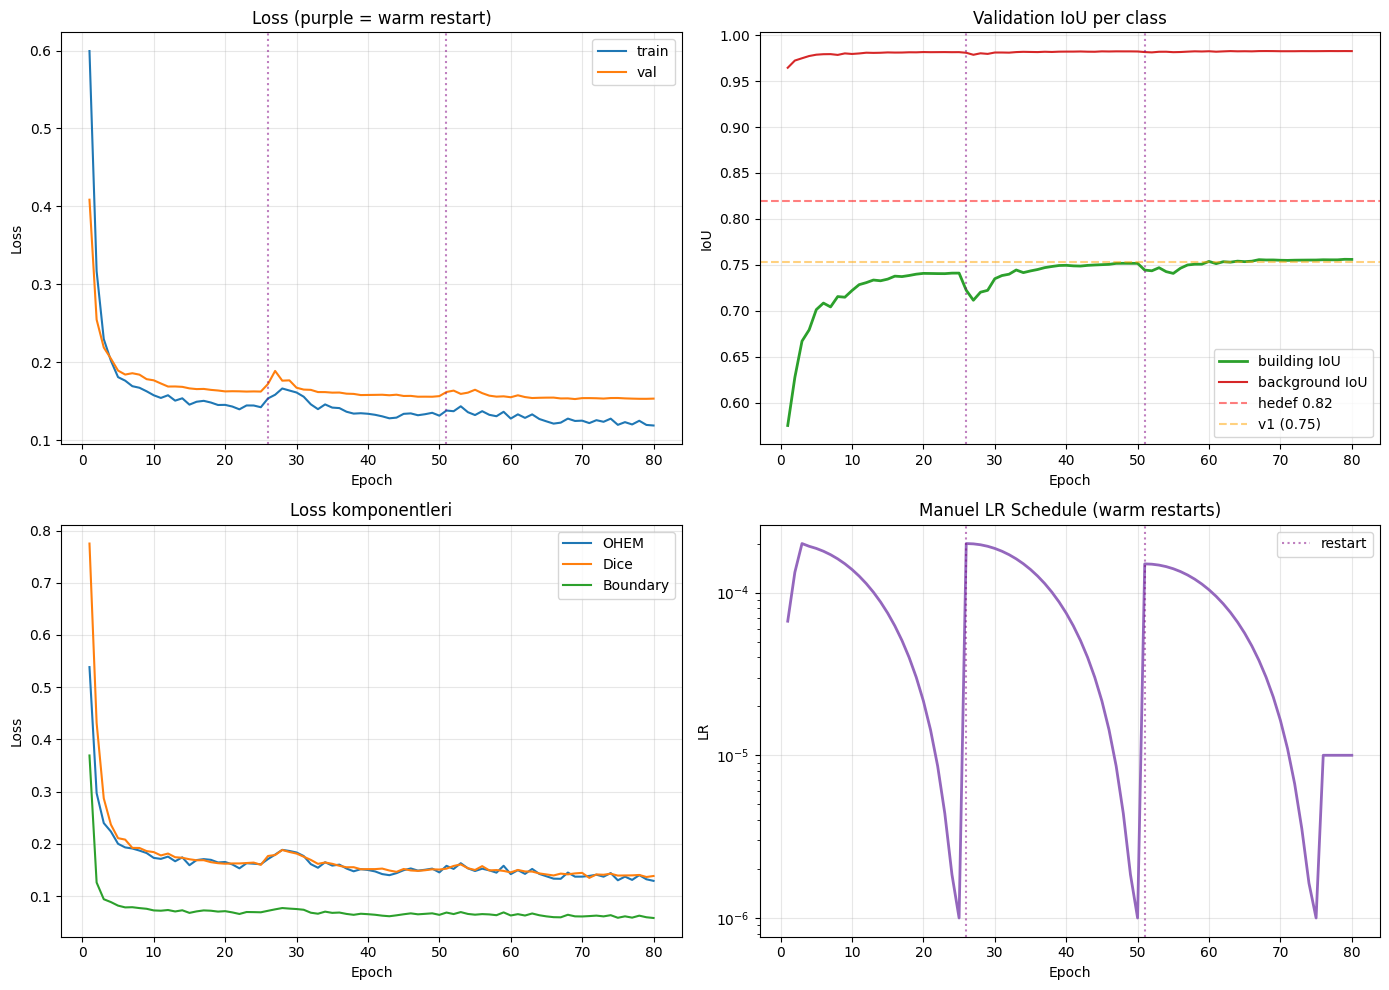

✅ /content/drive/MyDrive/AFETSONAR/outputs/visualizations/localizer_v2_predictions.png


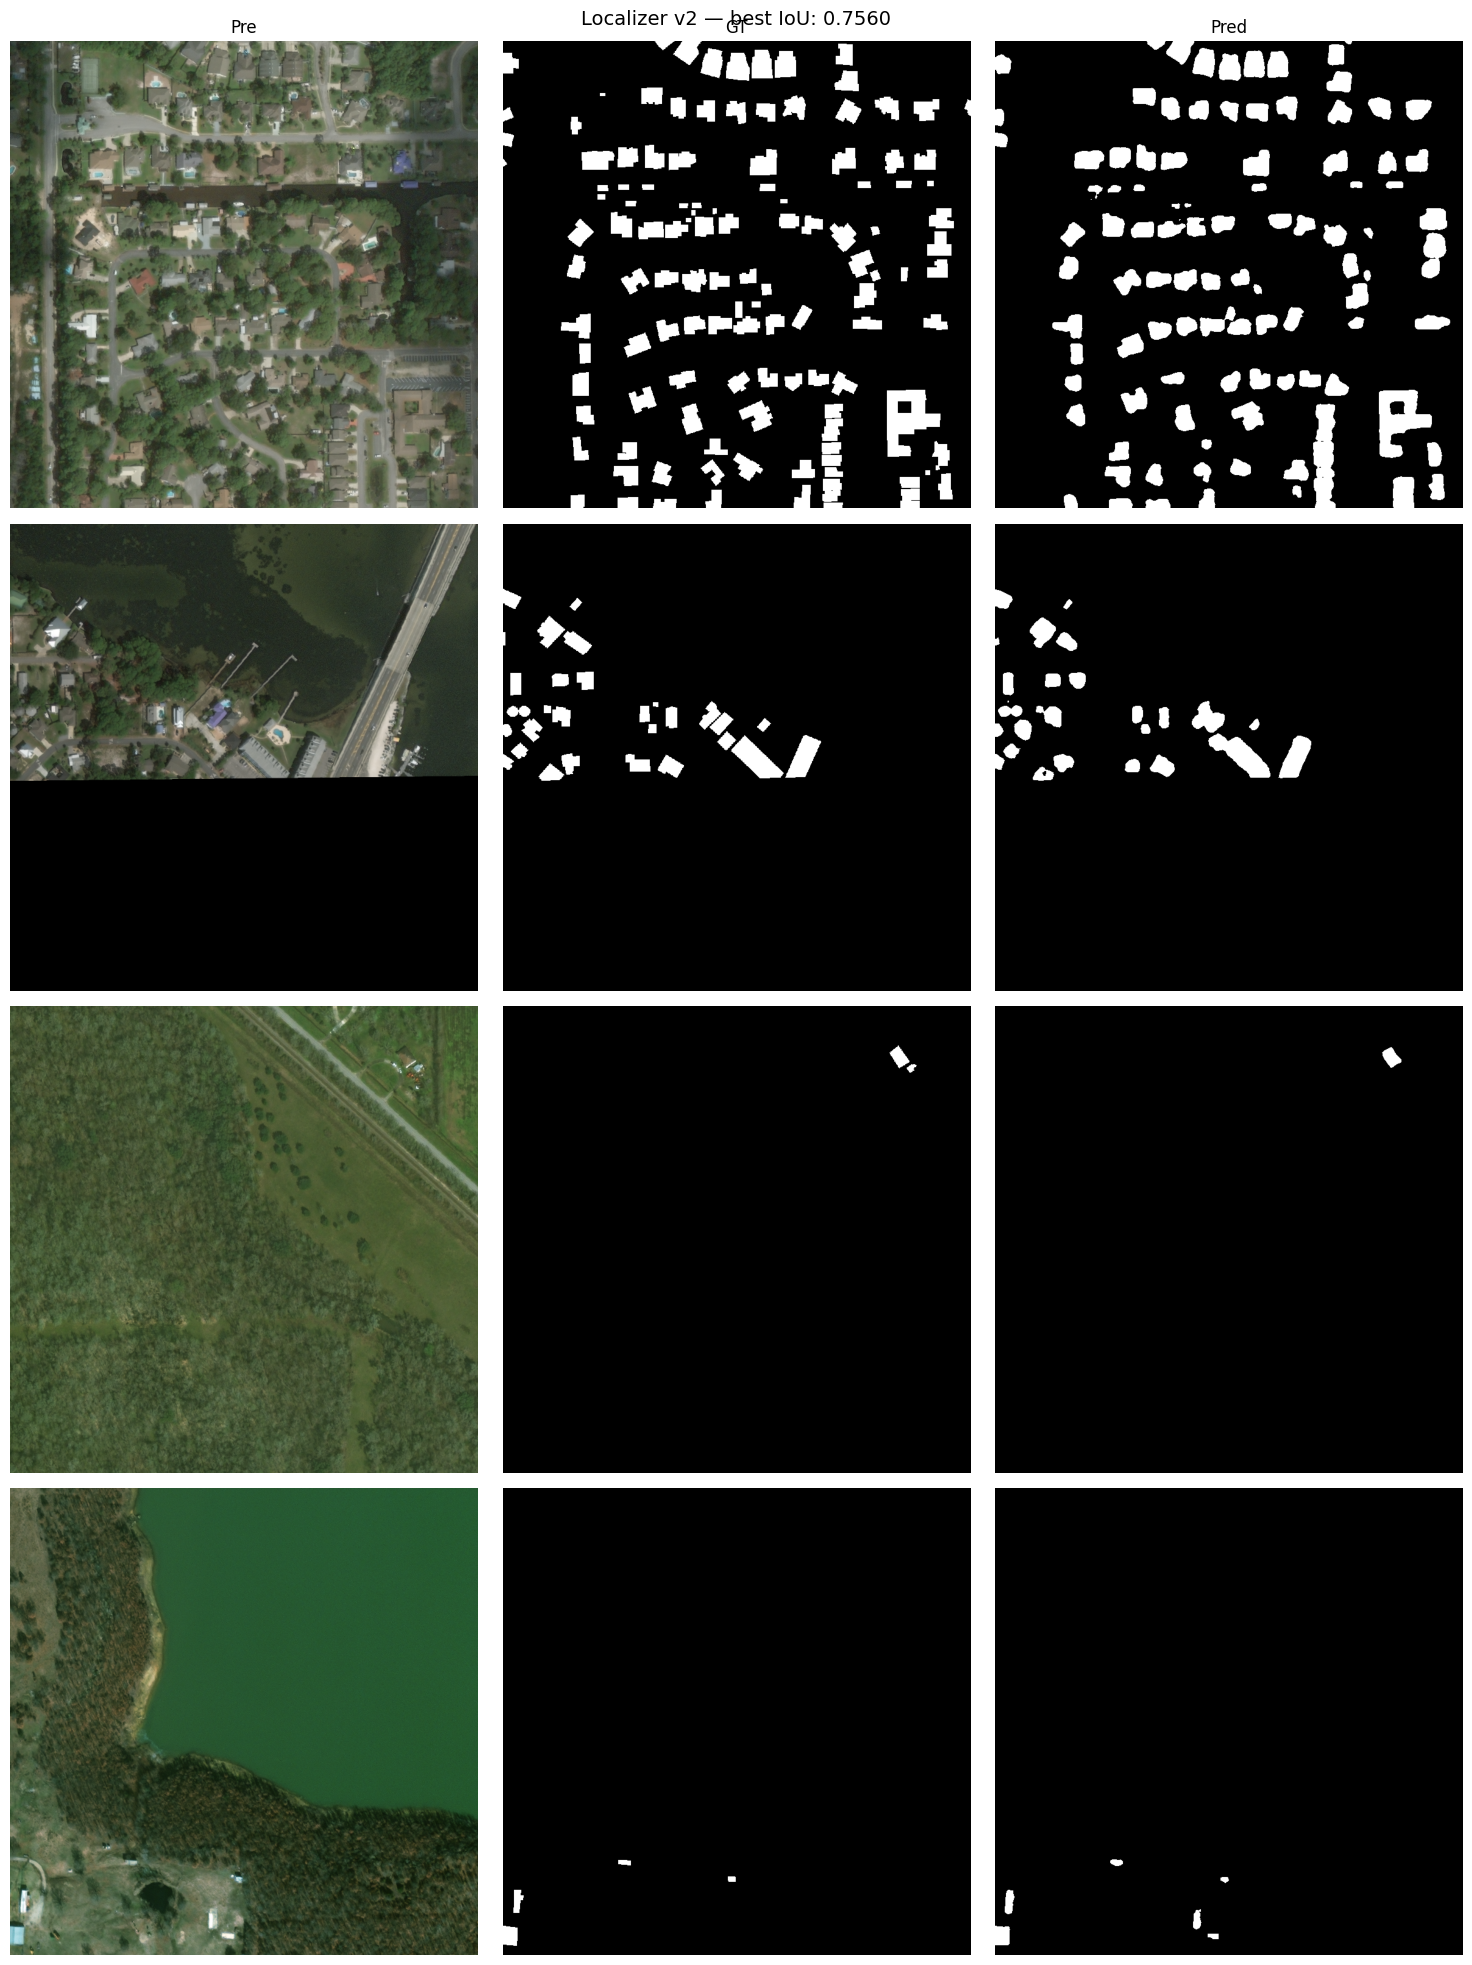

In [9]:
import matplotlib.pyplot as plt

with open(os.path.join(CKPT_TEACHER, "localizer_v2_history.json")) as f:
    history = json.load(f)

epochs = list(range(1, len(history["train_loss"]) + 1))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.plot(epochs, history["train_loss"], label="train", color="C0")
ax.plot(epochs, history["val_loss"], label="val", color="C1")
for r in [26, 51]:
    if r <= len(epochs):
        ax.axvline(r, color="purple", linestyle=":", alpha=0.5)
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Loss (purple = warm restart)")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(epochs, history["val_iou_building"], color="C2", linewidth=2, label="building IoU")
ax.plot(epochs, history["val_iou_bg"], color="C3", label="background IoU")
ax.axhline(y=0.82, color="red", linestyle="--", alpha=0.5, label="hedef 0.82")
ax.axhline(y=0.7533, color="orange", linestyle="--", alpha=0.5, label="v1 (0.75)")
for r in [26, 51]:
    if r <= len(epochs):
        ax.axvline(r, color="purple", linestyle=":", alpha=0.5)
ax.set_xlabel("Epoch"); ax.set_ylabel("IoU")
ax.set_title("Validation IoU per class")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(epochs, history["train_ohem"], label="OHEM", color="C0")
ax.plot(epochs, history["train_dice"], label="Dice", color="C1")
ax.plot(epochs, history["train_boundary"], label="Boundary", color="C2")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Loss komponentleri")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(epochs, history["lr"], color="C4", linewidth=2)
for r in [26, 51]:
    if r <= len(epochs):
        ax.axvline(r, color="purple", linestyle=":", alpha=0.5, label="restart" if r == 26 else None)
ax.set_xlabel("Epoch"); ax.set_ylabel("LR")
ax.set_title("Manuel LR Schedule (warm restarts)")
ax.set_yscale("log")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
fig_path = os.path.join(OUTPUTS_VIZ, "localizer_v2_training_curves.png")
plt.savefig(fig_path, dpi=100, bbox_inches="tight")
print(f"✅ {fig_path}")
plt.show()

# Tahmin görseli
ckpt = torch.load(os.path.join(CKPT_TEACHER, "localizer_v2_best.pth"),
                  map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

random.seed(42)
sample_indices = random.sample(range(len(val_ds)), 4)

fig, axes = plt.subplots(4, 3, figsize=(15, 20))

for row, idx in enumerate(sample_indices):
    sample = val_ds[idx]
    img_batch = sample["image"].unsqueeze(0).to(device)

    with torch.no_grad():
        with torch.autocast(device_type="cuda", dtype=amp_dtype):
            logits = model(img_batch)
        pred = logits.argmax(dim=1)[0].cpu()

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    pre = (sample["image"] * std + mean).permute(1, 2, 0).numpy().clip(0, 1)

    axes[row, 0].imshow(pre); axes[row, 0].set_title("Pre" if row == 0 else ""); axes[row, 0].axis("off")
    axes[row, 1].imshow(sample["mask"].numpy(), cmap="gray", vmin=0, vmax=1)
    axes[row, 1].set_title("GT" if row == 0 else ""); axes[row, 1].axis("off")
    axes[row, 2].imshow(pred.numpy(), cmap="gray", vmin=0, vmax=1)
    axes[row, 2].set_title("Pred" if row == 0 else ""); axes[row, 2].axis("off")

plt.suptitle(f"Localizer v2 — best IoU: {ckpt['val_iou_building']:.4f}", fontsize=14)
plt.tight_layout()
pred_path = os.path.join(OUTPUTS_VIZ, "localizer_v2_predictions.png")
plt.savefig(pred_path, dpi=80, bbox_inches="tight")
print(f"✅ {pred_path}")
plt.show()

## 🎉 Phase 1 v2 Tamamlandı!

### Karşılaştırma

| Metrik | v1 | v2 (umarım) |
|---|---|---|
| Building IoU | 0.7533 | ≥ 0.82 |
| Plato | epoch 5'te | yok (warm restarts) |
| LR bug | var | düzeltildi |
| Augmentation | zayıf | güçlü (scale + distortion + blur) |
| Loss | BCE+Dice | OHEM+Dice+Boundary |

### Bana Ne Gönder

1. Eğitim sonu console log (özellikle restart noktaları: epoch 26, 51, 76)
2. `localizer_v2_training_curves.png` — LR grafiği önemli, restart'lar görünmeli
3. `localizer_v2_predictions.png` — sınır kalitesi v1'den iyi mi

### Sonraki Adım

Eğer IoU ≥ 0.80 → **Phase 2'ye geç** (`02_v3_phase2_damage.ipynb`)
Eğer 0.75-0.80 → Phase 2'ye geç ama daha dikkatli
Eğer < 0.75 → Bana göster, debug edelim

---

**Calamitas AI · Teknofest 2025 · Phase 1 v2** 🚀